# Exercise 3B

In this exercise, you will explore how the DBSCAN clustering algorithm identifies dense groups and outliers in the Pokémon statistics dataset. You will analyze the dataset, scale features, determine DBSCAN parameters, run DBSCAN, and interpret the clustering results.

In [531]:
import kagglehub
import os
import pandas as pd

In [532]:
# Download latest version
path = kagglehub.dataset_download("abcsds/pokemon")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pokemon' dataset.
Path to dataset files: /kaggle/input/pokemon


In [533]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Load the Dataset (8 pts)

Load the Pokémon dataset into a pandas DataFrame.

Show the first five rows (3 pts)

In [534]:
# put your answer here
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False



How many Pokémon are in the dataset? (2 pts)


In [535]:
# put your answer here
df.shape

# There are 800 pokemons in the dataset.

(800, 13)


List all columns available (3 pts)

In [536]:
# put your answer here
df.columns


Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

## 2: Select Features & Clean the Data (8 pts)

Select the numeric features needed for clustering (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed).

How many rows remain after selecting these features? (3 pts)

In [537]:
# put your answer here
# df_X = df[['HP', 'Attack', 'Defense',
#        'Sp. Atk', 'Sp. Def', 'Speed']]

df_X = pd.DataFrame()

# df_X = df[['HP', 'Attack', 'Speed']]

df_X['Tankiness'] = (df['HP'] / df['HP'].mean() + df['Defense'] / df['Defense'].mean() + df['Sp. Def'] / df['Sp. Def'].mean())
# df_X['Special Tankiness']     = (df['Sp. Def'] / df['Sp. Def'].mean())
# df_X['Speed'] = df['Speed']
df_X['Offensive'] = (df['Sp. Atk'] / df['Sp. Atk'].mean() + df['Attack'] / df['Attack'].mean())
df_X['Speed'] = df['Speed']
df_X.head()

,Tankiness,Offensive,Speed
0,2.217314,1.512855,45
1,2.832102,1.883397,60
2,3.669875,2.411207,80
3,4.489723,2.941167,80
4,1.840812,1.482167,65


Are there any missing values? (2 pts)

In [538]:
# put your answer here
df_X.isnull().sum()

,0
Tankiness,0
Offensive,0
Speed,0


If missing values exist, describe how you handled them (3 pts)

In [539]:
# put your answer here

# There are no missing values


# 3. Scale the Features (10 pts)

Apply StandardScaler to the selected features.

Show the transformed feature sample (e.g., first 5 rows) (10 pts)


In [540]:
from IPython.lib.display import join
from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()
df_X['Offensive'] = scaler_standard.fit_transform(df_X[['Offensive']])
df_X['Speed'] = scaler_standard.fit_transform(df_X[['Speed']])
df_X['Tankiness'] = scaler_standard.fit_transform(df_X[['Tankiness']])
# df_X['Speed'] = scaler_standard.fit_transform(df_X[['Speed']])

df_X.values

df_X.head()





,Tankiness,Offensive,Speed
0,-0.868206,-0.677884,-0.801503
1,-0.186244,-0.162258,-0.285015
2,0.743068,0.572214,0.403635
3,1.652496,1.309677,0.403635
4,-1.285845,-0.720589,-0.112853


# Plotting the processed

In [541]:
import plotly.express as px

fig = px.scatter_3d(df_X, x='Tankiness', y='Offensive', z='Speed', width=1000, height=800)
fig.show()

# put your answer here
# plt.scatter(df_X['Offensive'], df_X['Speed'])
# plt.show()

## 4. Determine a Suitable eps Value (10 pts)

Using k = 4:
Compute the distance to the 4th nearest neighbor for each Pokémon (6 pts)

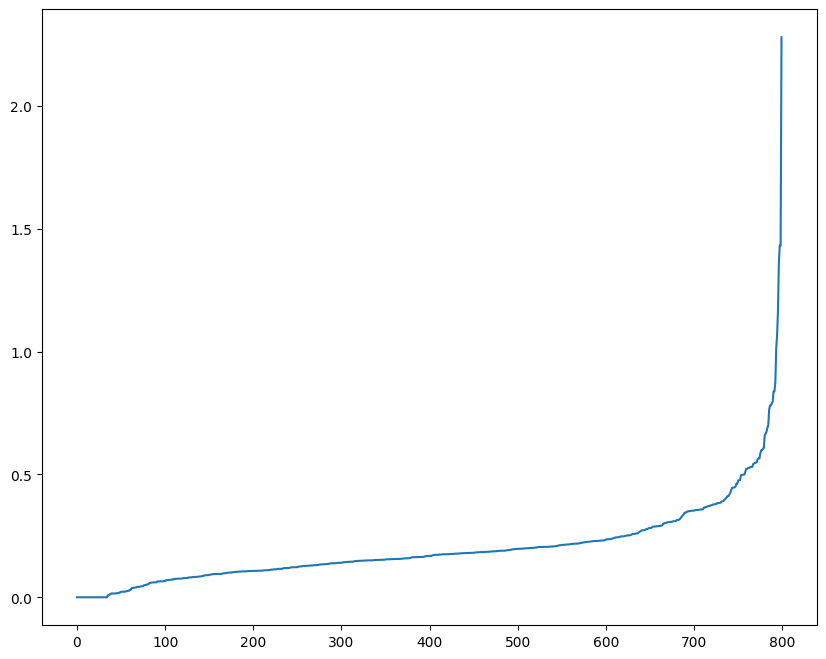

In [542]:
# put your answer here
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

nn = NearestNeighbors(n_neighbors=20).fit(df_X)
distances, indices = nn.kneighbors(df_X)



distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(10,8))
plt.plot(distances)



What is your chosen eps based on the "elbow"? (2 pts)

In [543]:
# Calculating the best variables
from sklearn.cluster import DBSCAN
from sklearn import metrics

min_samples = range(3,5)
# epsilon = np.arange(0.5, 0.75, 0.01)
epsilon = np.arange(0.3, 0.40, 0.01)
output = []

for ms in min_samples:
    for ep in epsilon:
        labels = DBSCAN(min_samples=ms, eps = ep).fit(df_X).labels_
        score = metrics.silhouette_score(df_X, labels)
        output.append((ms, ep, score))

min_samples, eps, score = sorted(output, key=lambda x:x[-1])[-1]
print(f"Best silhouette_score: {score}")
print(f"min_samples: {min_samples}")
print(f"eps: {eps}")


Best silhouette_score: 0.05485910483970541
min_samples: 3
eps: 0.39000000000000007


In [544]:
# put your answer here

# I chose the value of 0.39

In [545]:
# put your answer here

# I chose the value of 0.39 because that is the point where it seemed to began rising upwards rapidly. I also calculated it to have the best silhouette score with 0.39 epsilon and min sample of 3

One-sentence explanation of your reasoning (2 pts)

## 5. Run DBSCAN (10 points)

Run DBSCAN using your chosen eps and min_samples


How many clusters did DBSCAN find? (4 pts)

In [546]:
ep = eps
dbscan = DBSCAN(eps = ep, min_samples=min_samples).fit(df_X)
labels = dbscan.labels_

# Number of clusters in labels
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Number of noise
n_noise_ = list(labels).count(-1)

silhouette_score = metrics.silhouette_score(df_X, labels)

print("Estimated number of clusters: %d" % n_clusters_)

print("Silhouette scrore", silhouette_score)

Estimated number of clusters: 5
Silhouette scrore 0.05485910483970541


How many Pokémon were labeled as noise? (4 pts)

In [547]:
# put your answer here
print("Amount of Pokemons labeled as noise: %d" % n_noise_)

Amount of Pokemons labeled as noise: 96


Show the unique labels output by DBSCAN (2 pts)

In [548]:
fig = px.scatter_3d(df_X, x='Offensive', y='Tankiness', z='Speed', color=labels, width=1000, height=800)
fig.show()

# plt.scatter(df['Attack'], df['Sp. Atk'],
#             s = 80, c = labels)
# plt.legend()






## 6. Attach Cluster Labels to the Original Dataset (7 points)

Add the cluster labels back to the original DataFrame (3 pts)

In [549]:
# put your answer here
# fig = px.scatter_3d(df_X, x='Health', y='Trade', z='Finance', width=1000, height=800)
# fig.show()

df['Cluster'] = labels

Show the first 10 rows including the cluster label (4 pts)

In [550]:
# put your answer here
df.head(10)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Cluster
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,0
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,0
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,0
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,0
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,0
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False,0
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False,0
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False,0
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False,0
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False,0


## 7. Explore the Clusters (12 points)

For each cluster:


How many Pokémon does it contain? (4 pts)

In [551]:
# put your answer here
cluster_counts = df[df['Cluster'].isin([-1, 0, 1, 2, 3, 4])]['Cluster'].value_counts().sort_index()

print(cluster_counts)

Cluster
-1     96
 0    676
 1     16
 2      5
 3      4
 4      3
Name: count, dtype: int64


What are the average Attack, Defense, and Speed? (4 pts)


In [552]:
# put your answer here
column0 = df[df['Cluster'] == 0]
column1 = df[df['Cluster'] == 1]
column2 = df[df['Cluster'] == 2]
column3 = df[df['Cluster'] == 3]
column4 = df[df['Cluster'] == 4]
columnNoise = df[df['Cluster'] == -1]

print('Average Attack in Column 0: ', (column0['Attack'].mean()))
print('Average Attack in Column 1: ', (column1['Attack'].mean()))
print('Average Attack in Column 2: ', (column2['Attack'].mean()))
print('Average Attack in Column 3: ', (column3['Attack'].mean()))
print('Average Attack in Column 4: ', (column4['Attack'].mean()))
print('Average Attack in Column Noise: ', (columnNoise['Attack'].mean()))
print('\n')
print('Average Defense in Column 0: ', (column0['Defense'].mean()))
print('Average Defense in Column 1: ', (column1['Defense'].mean()))
print('Average Defense in Column 2: ', (column2['Defense'].mean()))
print('Average Defense in Column 3: ', (column3['Defense'].mean()))
print('Average Defense in Column 4: ', (column4['Defense'].mean()))
print('Average Defense in Column Noise: ', (columnNoise['Defense'].mean()))
print('\n')
print('Average Speed in Column 0: ', (column0['Speed'].mean()))
print('Average Speed in Column 1: ', (column1['Speed'].mean()))
print('Average Speed in Column 2: ', (column2['Speed'].mean()))
print('Average Speed in Column 3: ', (column3['Speed'].mean()))
print('Average Speed in Column 4: ', (column4['Speed'].mean()))
print('Average Speed in Column Noise: ', (columnNoise['Speed'].mean()))
print('\n')

Average Attack in Column 0:  76.39940828402366
Average Attack in Column 1:  136.375
Average Attack in Column 2:  127.0
Average Attack in Column 3:  71.25
Average Attack in Column 4:  121.66666666666667
Average Attack in Column Noise:  84.25


Average Defense in Column 0:  71.19822485207101
Average Defense in Column 1:  103.4375
Average Defense in Column 2:  69.0
Average Defense in Column 3:  144.0
Average Defense in Column 4:  130.0
Average Defense in Column Noise:  83.10416666666667


Average Speed in Column 0:  65.51183431952663
Average Speed in Column 1:  94.0625
Average Speed in Column 2:  110.4
Average Speed in Column 3:  50.0
Average Speed in Column 4:  113.33333333333333
Average Speed in Column Noise:  80.61458333333333




Compare the clusters: What differences do you notice? (4 pts)

Column 0 has a low average in Attack, Speed and Defense.

Column 4 seem to be high on all three aspects.

Column 3 tends to favor other stats over speed

Column 2 tends to have good attack and speed but low defense

Column 1 just tends to do slightly worse than Column 4 in regards to speed, but is just as good on other things.

## 8. Identify Outliers (10 points)

List all Pokémon labeled as noise (cluster = -1) (4 pts)

In [553]:
# put your answer here
print(columnNoise)

       #                   Name   Type 1  Type 2  Total  HP  Attack  Defense  \
13    10               Caterpie      Bug     NaN    195  45      30       35   
16    13                 Weedle      Bug  Poison    195  40      35       30   
19    15  BeedrillMega Beedrill      Bug  Poison    495  65     150       40   
55    50                Diglett   Ground     NaN    265  10      55       25   
56    51                Dugtrio   Ground     NaN    405  35      80       50   
..   ...                    ...      ...     ...    ...  ..     ...      ...   
773  703                Carbink     Rock   Fairy    500  50      50      150   
795  719                Diancie     Rock   Fairy    600  50     100      150   
796  719    DiancieMega Diancie     Rock   Fairy    700  50     160      110   
797  720    HoopaHoopa Confined  Psychic   Ghost    600  80     110       60   
798  720     HoopaHoopa Unbound  Psychic    Dark    680  80     160       60   

     Sp. Atk  Sp. Def  Speed  Generatio

Are many of them legendary? (3 pts)

In [554]:
# put your answer here
# yes there are 4 legendaries

Explain why DBSCAN might classify them as outliers (3 pts)

In [555]:
# put your answer here
# dbscan classified them as outliers because they are too far from the others in terms of stats

## 9. Interpret the Clustering Results (25 points)
Write a short interpretation (4–6 sentences).
Discuss:


What types of Pokémon grouped together (5 pts)

In [556]:
# put your answer here

# From my interpretation, Column 4 is the S+ tier pokemon. Column 1 is the S tier pokemon. Column 0 is B tier, average. Column 2 and 3 are A tiers but have clear flaws. Noise data is mixed, there are legendaries but there are also non legendary pokemon mixed in.

Whether the clusters make intuitive sense (10 pts)

In [557]:
# put your answer here
# Yes the clusters show clear differences in stats that ranks them in different tiers.


What the noise points reveal about DBSCAN (5 pts)


In [558]:
# put your answer here
# These reveal the outliers

What stat patterns you discovered (5 pts)

In [559]:
# put your answer here
# There are those who do everything well, there are those that do some well but some not, and some that are average on everything.